# Level 0 Day-Ahead Forecast Showcase

This notebook demonstrates the seasonal-naive forecasting module in `utils/forecast_level_0.py`: it forecasts household consumption from the matching 15-minute slot in prior weeks, backtests chronologically, and exports metrics and plots.

The default walkthrough uses household `100105` so it runs quickly. The complete meter collection is about 1.7 GB; the full-cohort run is an explicit opt-in near the end. The source data ends in February 2024 and contains consumption readings only, not PV generation.

## 1. Set Up Environment and Imports

The project dependencies are declared in `pyproject.toml`. This notebook checks the core versions instead of installing packages into the active kernel.

In [2]:
from datetime import date
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "utils" / "forecast_level_0.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "utils" / "forecast_level_0.py").exists(), "Open this notebook from the repository."

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs" / "forecast_level_0_showcase"
TEST_START = date(2024, 1, 1)
TEST_END = date(2024, 2, 27)
FORECAST_DATE = date(2024, 2, 29)
HOUSEHOLD_ID = "100105"  # Set to None only when intentionally running all households.
TIMEZONE = "Europe/Berlin"

pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 120)
print(f"pandas {pd.__version__}; notebook root: {ROOT}")

pandas 2.2.3; notebook root: /Users/p29135/Library/CloudStorage/OneDrive-E.ON/LearningPrograms/Hackathon_AI_for_Energy/rwth_hackathon_power_girls


## 2. Load the Previously Created Module or Script

Import the existing implementation rather than copying its forecasting logic into the notebook. The module exposes `forecast_day`, `run_forecast`, and `run_backtest`.

In [18]:
import importlib
from utils import forecast_level_0 as level0

level0 = importlib.reload(level0)
print("Module:", level0.__file__)
print("Target:", level0.TARGET_COLUMN)
print("Timezone:", level0.DEFAULT_TIMEZONE)
print("Forecast rule: previous matching weekday/15-minute slot; earlier weekly median if needed")

Module: /Users/p29135/Library/CloudStorage/OneDrive-E.ON/LearningPrograms/Hackathon_AI_for_Energy/rwth_hackathon_power_girls/utils/forecast_level_0.py
Target: kWh_received_Total
Timezone: Europe/Berlin
Forecast rule: previous matching weekday/15-minute slot; earlier weekly median if needed


## 3. Prepare Demo Input Data

Inspect the collection and one representative meter file. Missing target values remain missing; the forecaster uses only earlier observations for each prediction.

In [13]:
METER_FILES = sorted((DATA_DIR / "15min").glob("*.csv"))
print(f"Meter files: {len(METER_FILES)} | total size: {sum(path.stat().st_size for path in METER_FILES) / 1e9:.2f} GB")

sample_path = DATA_DIR / "15min" / f"{HOUSEHOLD_ID or METER_FILES[0].stem}.csv"
sample_meter = pd.read_csv(sample_path, sep=";", usecols=["Timestamp", level0.TARGET_COLUMN])
sample_meter["Timestamp"] = pd.to_datetime(sample_meter["Timestamp"], utc=True)
display(sample_meter.head())
display(sample_meter.isna().sum().rename("missing_rows").to_frame())
print(f"{sample_path.name}: {len(sample_meter):,} intervals, {sample_meter['Timestamp'].min()} to {sample_meter['Timestamp'].max()}")

Meter files: 410 | total size: 1.71 GB


,Timestamp,kWh_received_Total
0,2023-02-25 00:00:00+00:00,0.147
1,2023-02-25 00:15:00+00:00,0.742
2,2023-02-25 00:30:00+00:00,0.589
3,2023-02-25 00:45:00+00:00,0.146
4,2023-02-25 01:00:00+00:00,0.171


,missing_rows
Timestamp,0
kWh_received_Total,0


100105.csv: 34,464 intervals, 2023-02-25 00:00:00+00:00 to 2024-02-27 23:45:00+00:00


In [14]:
previous_week = pd.Timestamp("2024-01-08 12:00", tz=TIMEZONE).tz_convert("UTC")
target_slot = pd.Timestamp("2024-01-15 12:00", tz=TIMEZONE).tz_convert("UTC")
edge_history = pd.DataFrame(
    {
        "Timestamp": [previous_week, target_slot],
        level0.TARGET_COLUMN: [2.5, 999.0],  # The target-day value must not affect its forecast.
    }
)
edge_history

,Timestamp,kWh_received_Total
0,2024-01-08 11:00:00+00:00,2.5
1,2024-01-15 11:00:00+00:00,999.0


## 4. Run Core Features End-to-End

The demonstration backtest is chronological and limited to the selected household by default. It generates forecasts for every local day in the test window and scores only intervals with observed targets.

In [19]:
backtest_paths = level0.run_backtest(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    test_start=TEST_START,
    test_end=TEST_END,
    timezone=TIMEZONE,
    household_id=HOUSEHOLD_ID,
)

metrics = json.loads(backtest_paths["metrics"].read_text(encoding="utf-8"))
display(pd.Series(metrics, name="value").to_frame())
daily_totals = pd.read_csv(backtest_paths["daily_totals"])
display(daily_totals.head())

{
  "test_start": "2024-01-01",
  "test_end": "2024-02-27",
  "timezone": "Europe/Berlin",
  "households": 1,
  "possible_intervals": 5568,
  "forecastable_intervals": 5568,
  "scored_intervals": 5568,
  "interval_mae_kwh": 0.3124344468390805,
  "interval_rmse_kwh": 0.41533352972322884,
  "wape": 0.6954336798838784,
  "portfolio_signed_error_kwh": 57.08699999999994,
  "mean_bias_kwh_per_interval": 0.01025269396551723,
  "mean_daily_portfolio_absolute_error_kwh": 9.554568965517243
}
Wrote predictions, daily totals, metrics, and plot under /Users/p29135/Library/CloudStorage/OneDrive-E.ON/LearningPrograms/Hackathon_AI_for_Energy/rwth_hackathon_power_girls/outputs/forecast_level_0_showcase


,value
test_start,2024-01-01
test_end,2024-02-27
timezone,Europe/Berlin
households,1
possible_intervals,5568
forecastable_intervals,5568
scored_intervals,5568
interval_mae_kwh,0.312434
interval_rmse_kwh,0.415334
wape,0.695434


,EvaluationDate,ActualPortfolio_kWh,ForecastPortfolio_kWh,Error_kWh,ScoredIntervals
0,2024-01-01,45.506,34.934,-10.572,96
1,2024-01-02,55.757,40.154,-15.603,96
2,2024-01-03,35.158,45.426,10.268,96
3,2024-01-04,38.728,43.086,4.358,96
4,2024-01-05,44.351,33.448,-10.903,96


In [16]:
forecast_path = level0.run_forecast(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    forecast_date=FORECAST_DATE,
    timezone=TIMEZONE,
    household_id=HOUSEHOLD_ID,
)
next_day_forecasts = pd.read_csv(forecast_path)
next_day_forecasts.head(12)

Wrote 96 interval forecasts to /Users/p29135/Library/CloudStorage/OneDrive-E.ON/LearningPrograms/Hackathon_AI_for_Energy/rwth_hackathon_power_girls/outputs/forecast_level_0_showcase/forecasts_2024-02-29.csv


,Household_ID,Timestamp,Forecast_kWh,ForecastMethod
0,100105,2024-02-28 23:00:00+00:00,0.200,same_slot_previous_week
1,100105,2024-02-28 23:15:00+00:00,0.142,same_slot_previous_week
2,100105,2024-02-28 23:30:00+00:00,0.150,same_slot_previous_week
3,100105,2024-02-28 23:45:00+00:00,0.515,same_slot_previous_week
4,100105,2024-02-29 00:00:00+00:00,0.411,same_slot_previous_week
5,100105,2024-02-29 00:15:00+00:00,0.153,same_slot_previous_week
6,100105,2024-02-29 00:30:00+00:00,0.142,same_slot_previous_week
7,100105,2024-02-29 00:45:00+00:00,0.303,same_slot_previous_week
8,100105,2024-02-29 01:00:00+00:00,0.676,same_slot_previous_week
9,100105,2024-02-29 01:15:00+00:00,0.143,same_slot_previous_week


## 5. Visualize Outputs and Intermediate Results

The backtest exports both interval predictions and daily portfolio totals. These plots make under- and over-forecasting visible alongside the summary metrics.

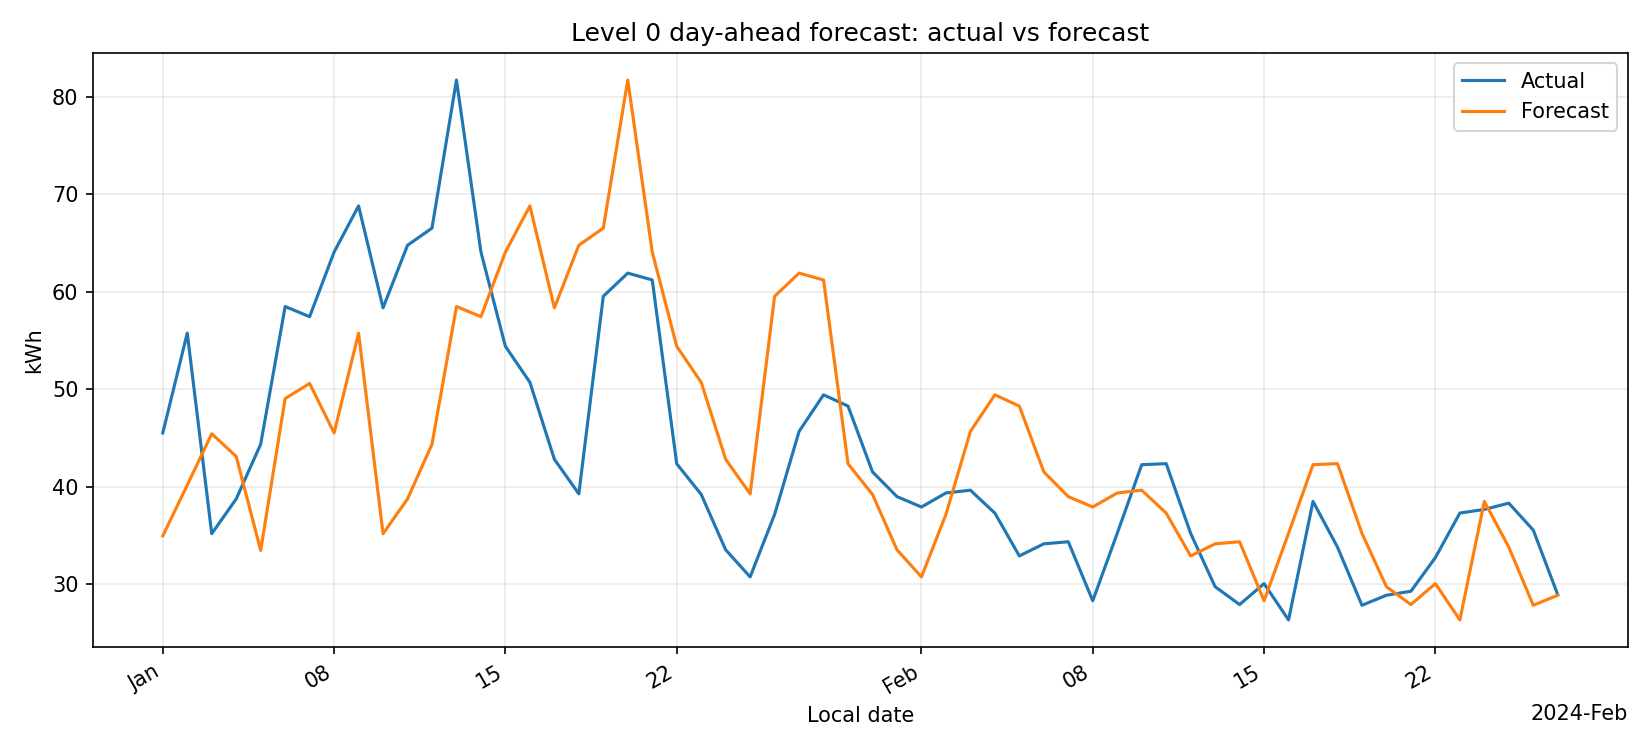

/var/folders/ng/rbgccf_s0bxch101bm3p9ykr0000gp/T/ipykernel_59470/1277927666.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
display(Image(filename=str(backtest_paths["plot"])))

prediction_rows = pd.read_csv(backtest_paths["predictions"])
example_day = prediction_rows.loc[prediction_rows["EvaluationDate"] == TEST_END.isoformat()].copy()
example_day["Timestamp"] = pd.to_datetime(example_day["Timestamp"], utc=True).dt.tz_convert(TIMEZONE)
axis = example_day.set_index("Timestamp")[["Actual_kWh", "Forecast_kWh"]].plot(figsize=(12, 4), alpha=0.85)
axis.set(title=f"Household {HOUSEHOLD_ID}: {TEST_END} actual vs forecast", ylabel="Interval energy (kWh)")
axis.grid(alpha=0.25)
figure = axis.get_figure()
interval_plot_path = OUTPUT_DIR / "interval_actual_vs_forecast.png"
figure.tight_layout()
figure.savefig(interval_plot_path, dpi=150)
plt.close(figure)
display(Image(filename=str(interval_plot_path)))

## 6. Add Interactive Controls for Exploration

If `ipywidgets` is available in the notebook kernel, choose a household and forecast date and click the button to rerun a single-household forecast. Otherwise, edit the constants in Section 1 and rerun the forecast cell.

In [9]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output
except ImportError:
    print("Interactive controls require ipywidgets. The fixed-parameter cells above still work.")
else:
    household_options = [path.stem for path in METER_FILES[:25]]
    if HOUSEHOLD_ID and HOUSEHOLD_ID not in household_options:
        household_options.insert(0, HOUSEHOLD_ID)
    household_picker = widgets.Dropdown(options=household_options, value=HOUSEHOLD_ID or household_options[0], description="Household")
    date_picker = widgets.DatePicker(value=FORECAST_DATE, description="Target date")
    run_button = widgets.Button(description="Run forecast", button_style="primary")
    widget_output = widgets.Output()

    def _run_selected_forecast(_):
        with widget_output:
            clear_output(wait=True)
            if date_picker.value is None:
                print("Choose a target date first.")
                return
            selected_output = level0.run_forecast(
                DATA_DIR, OUTPUT_DIR, date_picker.value, TIMEZONE, household_picker.value
            )
            display(pd.read_csv(selected_output).head(12))

    run_button.on_click(_run_selected_forecast)
    display(widgets.HBox([household_picker, date_picker, run_button]), widget_output)

Output()

## 7. Run Quick Validation Tests

Check the leakage edge case, daylight-saving day lengths, and the same end-to-end unit tests used for the module.

In [10]:
edge_result = level0.forecast_day(edge_history, "2024-01-15")
edge_forecast = edge_result.loc[edge_result["Timestamp"] == target_slot, "Forecast_kWh"].iloc[0]
assert edge_forecast == 2.5, "Forecast must use the earlier matching slot, not target-day data."
assert len(level0.forecast_day(pd.DataFrame(columns=["Timestamp", level0.TARGET_COLUMN]), "2024-03-31")) == 92
print("Leakage and DST checks passed.")

import subprocess
import sys

test_result = subprocess.run(
    [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)
print(test_result.stdout)
print(test_result.stderr)

Leakage and DST checks passed.
{
  "test_start": "2024-01-15",
  "test_end": "2024-01-15",
  "timezone": "Europe/Berlin",
  "households": 1,
  "possible_intervals": 96,
  "forecastable_intervals": 96,
  "scored_intervals": 96,
  "interval_mae_kwh": 1.0,
  "interval_rmse_kwh": 1.0,
  "wape": 0.5,
  "portfolio_signed_error_kwh": -96.0,
  "mean_bias_kwh_per_interval": -1.0,
  "mean_daily_portfolio_absolute_error_kwh": 96.0
}
Wrote predictions, daily totals, metrics, and plot under /var/folders/ng/rbgccf_s0bxch101bm3p9ykr0000gp/T/tmpip8tci00/output

test_backtest_writes_predictions_metrics_and_daily_totals (test_forecast_level_0.BacktestTests.test_backtest_writes_predictions_metrics_and_daily_totals) ... ok
test_falls_back_to_median_of_earlier_weekly_slots (test_forecast_level_0.ForecastDayTests.test_falls_back_to_median_of_earlier_weekly_slots) ... ok
test_local_day_has_correct_interval_count_across_dst (test_forecast_level_0.ForecastDayTests.test_local_day_has_correct_interval_count_acro

## 8. Export Demo Artifacts

Copy the selected sample outputs into one shareable folder. Set the full-cohort switch to `True` only when you are ready to read and backtest the entire meter collection.

In [11]:
import shutil

SHARE_DIR = OUTPUT_DIR / "shareable"
SHARE_DIR.mkdir(parents=True, exist_ok=True)
export_files = {
    "single_household_backtest_metrics.json": backtest_paths["metrics"],
    "single_household_daily_totals.csv": backtest_paths["daily_totals"],
    "single_household_backtest_plot.png": backtest_paths["plot"],
    "next_day_forecasts.csv": forecast_path,
}
for export_name, source_path in export_files.items():
    shutil.copy2(source_path, SHARE_DIR / export_name)
print("Exported artifacts:")
for exported_path in sorted(SHARE_DIR.iterdir()):
    print(exported_path.name, f"({exported_path.stat().st_size:,} bytes)")

RUN_FULL_COHORT = False  # Opt in only when ready to process the full ~1.7 GB dataset.
if RUN_FULL_COHORT:
    full_cohort_outputs = level0.run_backtest(
        DATA_DIR, OUTPUT_DIR / "full_cohort", TEST_START, TEST_END, TIMEZONE, household_id=None
    )
    print(full_cohort_outputs)
else:
    print("Full-cohort backtest skipped; set RUN_FULL_COHORT=True to run it.")

Exported artifacts:
next_day_forecasts.csv (6,086 bytes)
single_household_backtest_metrics.json (487 bytes)
single_household_backtest_plot.png (136,603 bytes)
single_household_daily_totals.csv (3,231 bytes)
Full-cohort backtest skipped; set RUN_FULL_COHORT=True to run it.
